### Base Analysis

This notebook is for the base analysis and cleaning of the dataset.

# 1. Learning & Cleaning the Data

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file

df_full = pd.read_csv('C:/Users/Kura/ddi/projects/launches/data/space_devs_launches_2010_2026.csv')

In [3]:
# Printing out the columns (there are WAY too many)

for col in df_full.columns:
    print(col)

id
url
name
response_mode
slug
launch_designator
last_updated
net
window_end
window_start
infographic
probability
weather_concerns
failreason
hashtag
mission
webcast_live
program
orbital_launch_attempt_count
location_launch_attempt_count
pad_launch_attempt_count
agency_launch_attempt_count
orbital_launch_attempt_count_year
location_launch_attempt_count_year
pad_launch_attempt_count_year
agency_launch_attempt_count_year
status.id
status.name
status.abbrev
status.description
net_precision.id
net_precision.name
net_precision.abbrev
net_precision.description
image.id
image.name
image.image_url
image.thumbnail_url
image.credit
image.license.id
image.license.name
image.license.priority
image.license.link
image.single_use
image.variants
launch_service_provider.response_mode
launch_service_provider.id
launch_service_provider.url
launch_service_provider.name
launch_service_provider.abbrev
launch_service_provider.type.id
launch_service_provider.type.name
rocket.id
rocket.configuration.response_m

In [4]:
# Shortening the dataset by specifying what columns to keep

cols_to_keep = ['id', 'name', 'launch_designator', 'net', 'window_end', 'window_start','failreason',
                'status.name', 'status.abbrev', 'launch_service_provider.name', 'launch_service_provider.type.name',
                'rocket.configuration.name', 'rocket.configuration.full_name', 'rocket.configuration.families',
                'mission.name', 'mission.type', 'mission.orbit.name', 'mission.orbit.abbrev', 'pad.name', 'pad.location.name',
                'pad.country.name', 'pad.latitude', 'pad.longitude']

df = df_full[cols_to_keep].copy()

In [5]:
# Renaming columns so they are easier to use

df = df.rename(columns={
    "id": "launch_id",
    "name": "launch_name",
    "launch_designator": "launch_designator",
    "net": "launch_datetime",
    "window_end": "launch_window_end",
    "window_start": "launch_window_start",
    "failreason": "failure_reason",

    "status.name": "status",
    "status.abbrev": "status_abbrev",

    "launch_service_provider.name": "launch_provider",
    "launch_service_provider.type.name": "provider_type",

    "rocket.configuration.name": "rocket_name",
    "rocket.configuration.full_name": "rocket_full_name",
    "rocket.configuration.families": "rocket_family",

    "mission.name": "mission_name",
    "mission.type": "mission_type",
    "mission.orbit.name": "orbit",
    "mission.orbit.abbrev": "orbit_abbrev",

    "pad.name": "launch_pad",
    "pad.location.name": "launch_location",
    "pad.country.name": "launch_country",
    "pad.latitude": "pad_latitude",
    "pad.longitude": "pad_longitude"
})

# Convert date columns to datetime
df['launch_datetime'] = pd.to_datetime(df['launch_datetime'], errors='coerce')
df['launch_window_start'] = pd.to_datetime(df['launch_window_start'], errors='coerce')
df['launch_window_end'] = pd.to_datetime(df['launch_window_end'], errors='coerce')

# Create useful time columns for analysis
df['year'] = df['launch_datetime'].dt.year
df['month'] = df['launch_datetime'].dt.month
df['quarter'] = df['launch_datetime'].dt.quarter

In [6]:
# Saving cleaned dataset
df.to_csv('C:/Users/Kura/ddi/projects/launches/data/space_devs_launches_cleaned.csv', index=False)

In [7]:
# Separating current and future planned launches

planned_launches = df[
    df['status'].isin(["To Be Confirmed", "To Be Determined", "Go for Launch"])
].copy()

launches_df = df[
    ~df['status'].isin(["To Be Confirmed", "To Be Determined", "Go for Launch"])
].copy()

In [8]:
# Quick look at the cleaned dataset

launches_df.head()

,launch_id,launch_name,launch_designator,launch_datetime,launch_window_end,launch_window_start,failure_reason,status,status_abbrev,launch_provider,...,orbit,orbit_abbrev,launch_pad,launch_location,launch_country,pad_latitude,pad_longitude,year,month,quarter
0,bb643566-508a-4f3a-a701-85669d11e2b3,Long March 3C | Compass-G1,2010-001,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,NaN,NaN,Launch Complex 2 (LC-2),"Xichang Satellite Launch Center, People's Repu...",China,28.245504,102.026768,2010,1,1
1,470aff2b-3cc8-4e98-9ada-d511828b4676,Proton-M / Briz-M Enhanced | Globus-1M #12L (R...,2010-002,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,NaN,Launch Successful,Success,Khrunichev State Research and Production Space...,...,NaN,NaN,81/24 (81P),"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,46.071001,62.984999,2010,1,1
2,cb3977fe-3ef4-46d2-8bc9-65a0d9cef07a,Soyuz-U | Progress M-04M (36P),2010-003,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,NaN,Launch Successful,Success,Russian Federal Space Agency (ROSCOSMOS),...,NaN,NaN,1/5,"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,45.920000,63.342000,2010,2,1
3,80db2215-04bd-4d16-b998-311fb73db4fe,Space Shuttle Endeavour / OV-105 | STS-130,2010-004,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,NaN,Launch Successful,Success,United Space Alliance,...,Low Earth Orbit,LEO,Launch Complex 39A,"Kennedy Space Center, FL, USA",United States of America,28.608227,-80.604282,2010,2,1
4,7e4160fc-c9d5-4db6-b9b1-166408741f0e,Atlas V 401 | SDO (Solar Dynamics Observatory),2010-005,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,NaN,Launch Successful,Success,United Launch Alliance,...,Enhanced Geostationary Transfer Orbit,Enhanced-GTO,Space Launch Complex 41,"Cape Canaveral SFS, FL, USA",United States of America,28.583410,-80.583036,2010,2,1


In [9]:
# There are a LOT of null values in this dataset
# Many are to be expected, such as failure_reason but others may be dropped with if necessary in analysis

print(launches_df.shape)
launches_df.info()

# Dropped probability as that's probably only needed for weather analysis, and many null values

(2306, 26)
<class 'pandas.core.frame.DataFrame'>
Index: 2306 entries, 0 to 2305
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   launch_id            2306 non-null   object             
 1   launch_name          2306 non-null   object             
 2   launch_designator    2211 non-null   object             
 3   launch_datetime      2306 non-null   datetime64[ns, UTC]
 4   launch_window_end    2306 non-null   datetime64[ns, UTC]
 5   launch_window_start  2306 non-null   datetime64[ns, UTC]
 6   failure_reason       78 non-null     object             
 7   status               2306 non-null   object             
 8   status_abbrev        2306 non-null   object             
 9   launch_provider      2306 non-null   object             
 10  provider_type        2306 non-null   object             
 11  rocket_name          2306 non-null   object             
 12  rocket_full_na

In [10]:
# Checking for duplicates

print(f"Full row duplicates: {launches_df.duplicated().sum()}")
print(f"Launch id duplicates: {launches_df['launch_id'].duplicated().sum()}")
print(f"Launch name duplicates: {launches_df['launch_name'].duplicated().sum()}")

# Checks actual duplicates
# launches_df[launches_df["launch_name"].duplicated(keep=False)].sort_values("launch_name")

# Decided not to drop these rows as the IDs are distinct and are likely separate launch events

Full row duplicates: 0
Launch id duplicates: 0
Launch name duplicates: 19


# 2. Base Statistics

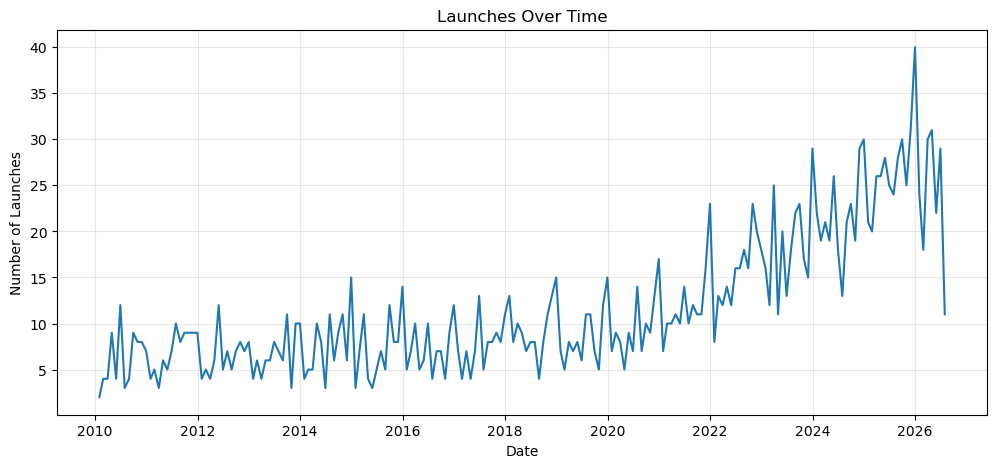

In [11]:
# Quick overview (full time analysis is found in time_series.ipynb)

launches_by_month = (
    launches_df.set_index('launch_datetime')
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(launches_by_month.index, launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

# That's really interesting?? Why does it spike so much in the end? Maybe confirm later with some other data for launches in 2026

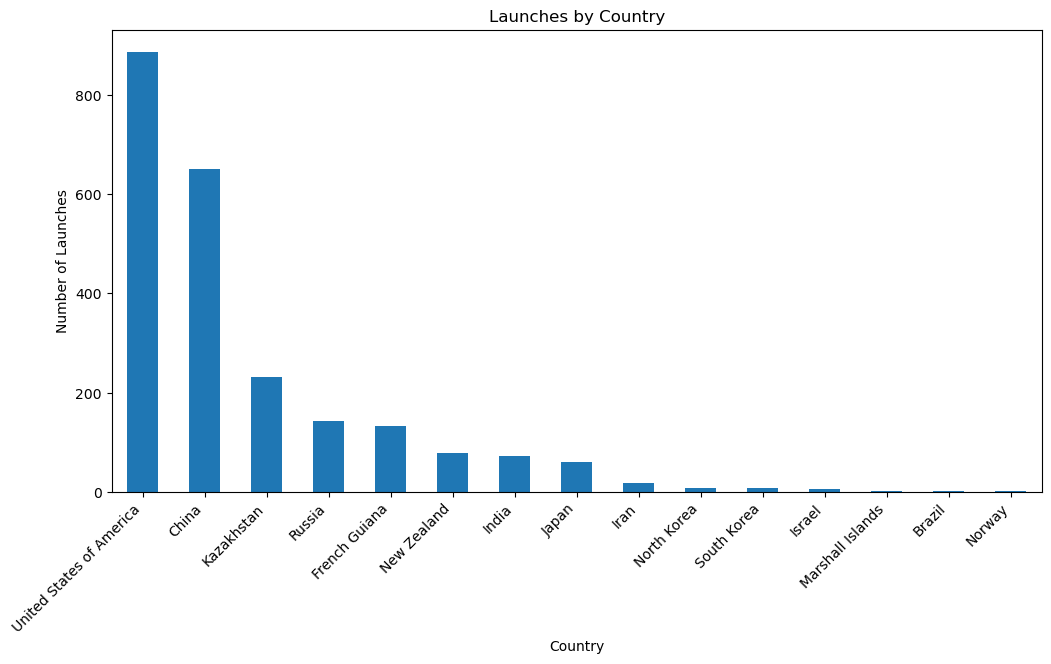

In [12]:
# Getting launches by country

launches_by_country = launches_df.groupby('launch_country').size().sort_values(ascending=False)
top_countries = launches_by_country.head(15)

plt.figure(figsize=(12, 6))

top_countries.plot(kind='bar')

plt.title("Launches by Country")
plt.xlabel('Country')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

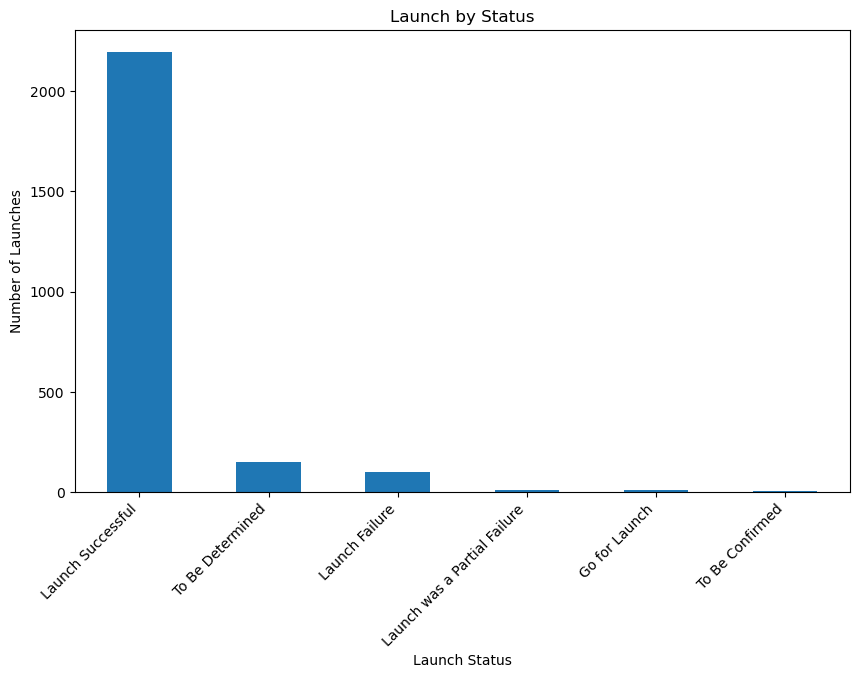

In [13]:
# Launches by status, this includes future/planned launches

launch_status = df.groupby('status').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

launch_status.plot(kind='bar')

plt.title('Launch by Status')
plt.xlabel('Launch Status')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

In [14]:
# Want to do a check on the spike of 2026 launches found in the time series analysis

launches_2026 = df[df['year'] == 2026]

# Check for launches that haven't happened yet
launches_2026[launches_2026['month'] > 6]

# Check for launches with the "To Be Determined" status - 149 launches
future_launches = df[df['status'] == 'To Be Determined']
future_launches

# Check for month distribution of future_launches
future_launches.groupby('month').size().sort_values()

# As seen, there are 109 launches scheduled for December, a dispraporionate amount to previous records

month
11      2
10      4
7       8
8       9
9      17
12    109
dtype: int64

In [15]:
# The amount of launches in 2026 are not extremely significant compared to other years,  there only seems to be a spike during December
# Note, these are all TO BE DETERMINED, none of these launches have happened yet

df.groupby('year').size()

year
2010     74
2011     84
2012     78
2013     81
2014     93
2015     87
2016     86
2017     91
2018    114
2019    102
2020    115
2021    145
2022    186
2023    221
2024    260
2025    324
2026    328
dtype: int64

In [16]:
# Launches by Country Over Time
country_year = launches_df.groupby(['year', 'launch_country']).size().reset_index(name='launch_count')

top5_by_year = (
    country_year.sort_values(['year', 'launch_count'], ascending=[True, False]).groupby('year').head(5)
)

top5_by_year.tail(20)

# The US has been the top for the past 3 years, with China in second

,year,launch_country,launch_count
128,2023,United States of America,106
116,2023,China,67
125,2023,Russia,10
122,2023,Kazakhstan,9
118,2023,India,7
138,2024,United States of America,141
129,2024,China,68
135,2024,New Zealand,13
137,2024,Russia,9
134,2024,Kazakhstan,8


# 3. Success Rates, Orbits, & Providers

<Figure size 1600x600 with 0 Axes>

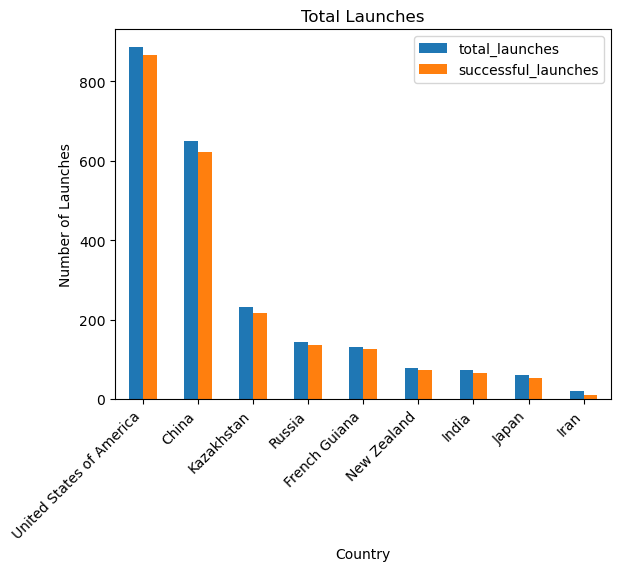

In [17]:
# Success rate by country

# Count successful launches
success_by_country = (
    launches_df.groupby('launch_country').agg(
        total_launches=('launch_id', 'count'),
        successful_launches=('status', lambda x: (x == 'Launch Successful').sum())
    )
)

# Create success rate
success_by_country['success_rate'] = (
    success_by_country['successful_launches'] / success_by_country['total_launches'] * 100
)

# Round
success_by_country['success_rate'] = success_by_country['success_rate'].round(2)

# Filter out countries with less than 6 total launches so the success_rate doesn't look inflated
success_by_country = success_by_country[
    success_by_country['total_launches'] >= 10
].sort_values('success_rate', ascending=False)

success_by_country

# United States probably has the most significant success rate (Israel only had 6 total launches, so their success rate being 100% is not very impressive)


# Plotting the total launches compared to successful launches by country
total_launches = success_by_country.sort_values('total_launches', ascending=False)

plt.figure(figsize=(16, 6))

total_launches[['total_launches', 'successful_launches']].plot(kind='bar')

plt.title('Total Launches')
plt.xlabel('Country')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

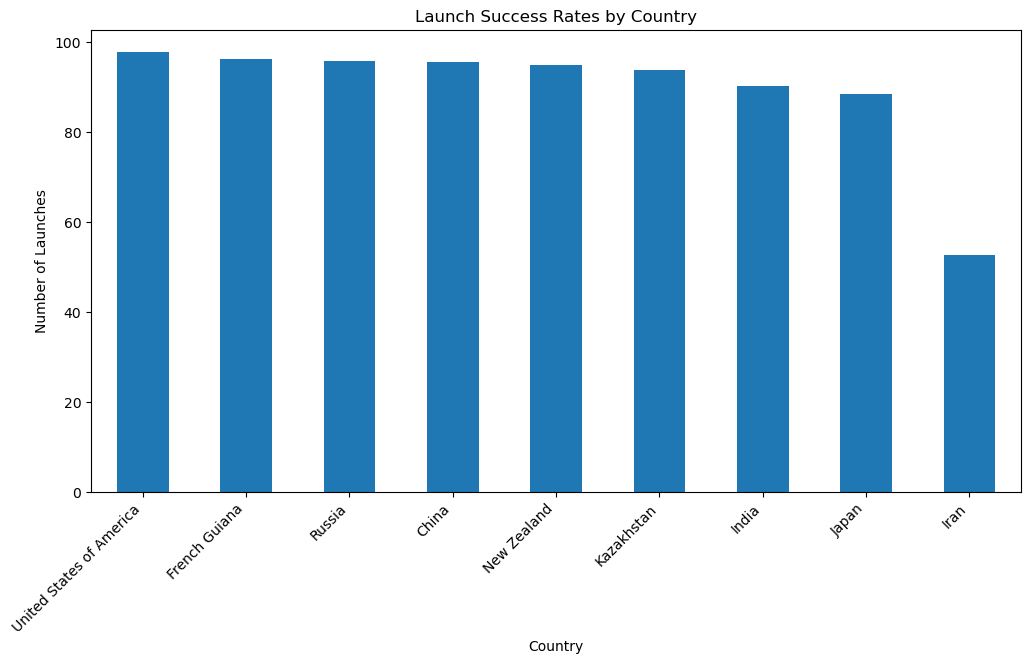

In [18]:
# Launch Success Rates by Country

plt.figure(figsize=(12, 6))

success_by_country['success_rate'].plot(kind='bar')

plt.title('Launch Success Rates by Country')
plt.xlabel('Country')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

# This feels less useful

In [19]:
# Orbits by geography

orbit_geo = pd.crosstab(launches_df['launch_country'], launches_df['orbit_abbrev'])

orbit_geo

# China dominates SSO, US dominates LEO - there's a lot of interesting data to look into here
# China/US missions may differ when launching satellites. The US is also heavily saturated from Starlink/SpaceX launches (usually LEO launches

orbit_abbrev,Asteroid,Direct-GEO,Elliptical,Enhanced-GTO,GSO,GSTO,GTO,HEO,Helio-N/A,Jupiter Orbit,L1-point,L2,LEO,LO,Lunar flyby,MEO,Mars,PO,SSO,Super-GTO
launch_country,,,,,,,,,,,,,,,,,,,,
Australia,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
China,1,1,3,0,2,3,84,1,1,0,0,0,166,7,0,16,0,38,200,0
French Guiana,0,0,1,0,0,0,59,0,2,0,1,2,9,0,0,18,0,3,32,1
India,0,0,1,0,0,4,15,0,0,0,1,0,16,2,0,0,0,2,17,0
Iran,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,0
Israel,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0
Japan,0,0,1,0,0,5,9,0,3,0,0,0,15,1,0,0,0,0,27,0
Kazakhstan,0,3,3,0,1,0,33,0,1,0,0,1,103,0,0,4,0,5,7,0


The obseved pattern likely reflects differences in mission mix between US and China. China's launhes appear to be more concentrated in Earth-observation-style SSO missions, whils US LEO launches are likely strongly influenced by commerical constallation deployment, especially Starlink.

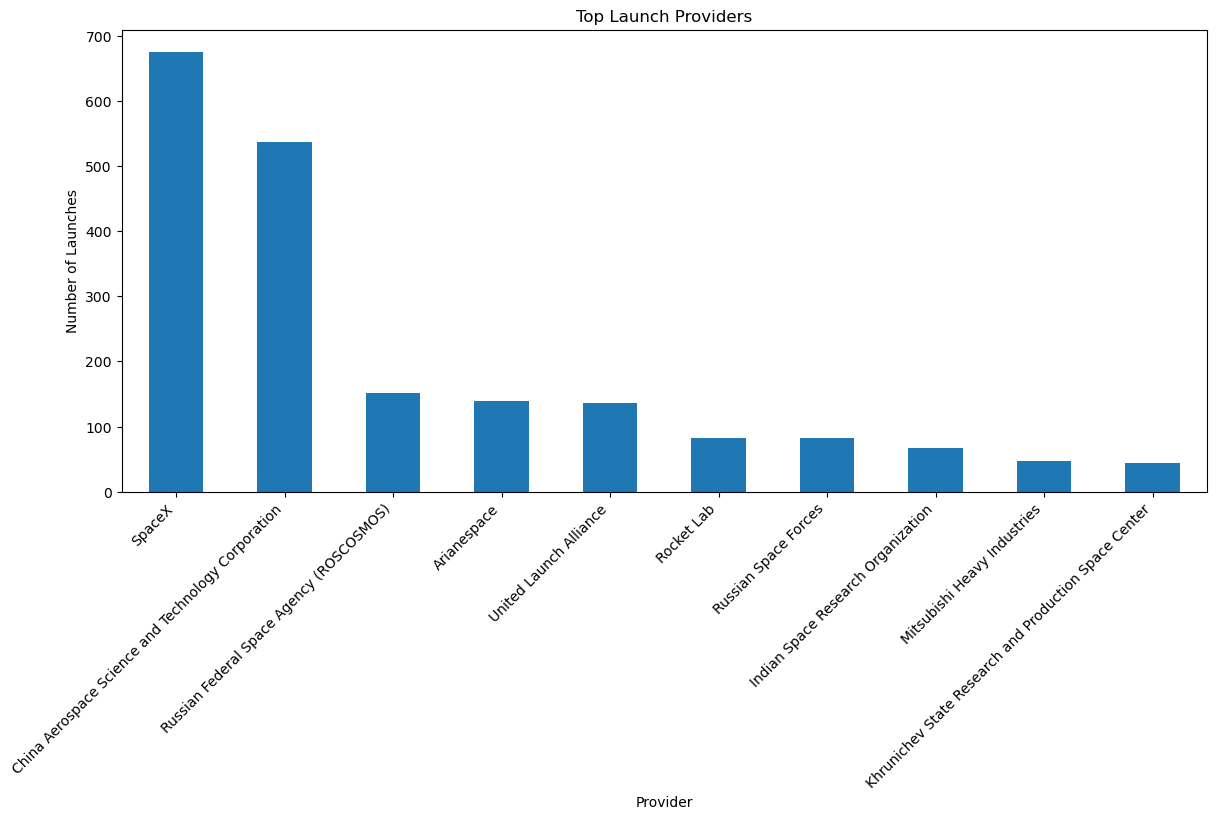

In [20]:
# Looking at who dominates the launch scene
# As expected, SpaceX is number 1

top_providers = launches_df['launch_provider'].value_counts().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))

top_providers.plot(kind='bar')

plt.title('Top Launch Providers')
plt.xlabel('Provider')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Prediction Model

In [21]:
# Create the target variable

launches_model = launches_df.copy()

launches_model['success'] = launches_model['status'].eq('Launch Successful').astype(int)

In [22]:
# Model Setup

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Defining features
features = [
    'year',
    'launch_provider',
    'provider_type',
    'rocket_full_name',
    'mission_type',
    'orbit_abbrev',
    'launch_country',
    'launch_pad',
    'rocket_family'
]

X = launches_model[features]
y = launches_model['success']

categorical_features = [
    'launch_provider',
    'provider_type',
    'rocket_full_name',
    'mission_type',
    'orbit_abbrev',
    'launch_country',
    'launch_pad',
    'rocket_family'
]

numeric_features = ['year']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=5000, class_weight='balanced'))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.14      0.50      0.21        22
           1       0.97      0.84      0.90       440

    accuracy                           0.82       462
   macro avg       0.55      0.67      0.56       462
weighted avg       0.93      0.82      0.87       462

[[ 11  11]
 [ 70 370]]


The first model made 70 false failure predictions and has a low F1-score.

Launch success is difficult to predict using such a high level of data. I tweaked the model so that it's able to catch 50% of the failures when they happen, but these failures are likely more to do with engineering/mechanical flaws than the data presented here. There are not enough failures that happen in this dataset to truly predict when failures happen. 

While the model can identify broad risk patterns, failures are rare events driven by technical factors not fully captured in this dataset. Nonetheless, it is still interesting the investigate.

# 5. Recreating the Model with More Features

In [30]:
# Data cleaning

rename_map = {
    "id": "launch_id",
    "name": "launch_name",
    "slug": "launch_slug",
    "launch_designator": "launch_designator",
    "net": "launch_datetime",
    "window_start": "launch_window_start",
    "window_end": "launch_window_end",
    "probability": "launch_probability",
    "weather_concerns": "weather_concerns",
    "failreason": "failure_reason",

    "status.name": "status",
    "status.abbrev": "status_abbrev",
    "status.description": "status_description",

    "net_precision.name": "date_precision",
    "net_precision.abbrev": "date_precision_abbrev",
    "net_precision.description": "date_precision_description",

    "launch_service_provider.name": "launch_provider",
    "launch_service_provider.abbrev": "provider_abbrev",
    "launch_service_provider.type.name": "provider_type",

    "rocket.configuration.name": "rocket_name",
    "rocket.configuration.full_name": "rocket_full_name",
    "rocket.configuration.families": "rocket_family",
    "rocket.configuration.variant": "rocket_variant",

    "mission.name": "mission_name",
    "mission.type": "mission_type",
    "mission.orbit.name": "orbit",
    "mission.orbit.abbrev": "orbit_abbrev",

    "pad.name": "launch_pad",
    "pad.active": "pad_active",
    "pad.latitude": "latitude",
    "pad.longitude": "longitude",
    "pad.country.name": "launch_country",
    "pad.location.name": "launch_location",
    "pad.location.timezone_name": "launch_timezone",

    "orbital_launch_attempt_count": "orbital_attempt_number",
    "location_launch_attempt_count": "location_attempt_number",
    "pad_launch_attempt_count": "pad_attempt_number",
    "agency_launch_attempt_count": "provider_attempt_number",

    "orbital_launch_attempt_count_year": "yearly_orbital_attempt_number",
    "location_launch_attempt_count_year": "yearly_location_attempt_number",
    "pad_launch_attempt_count_year": "yearly_pad_attempt_number",
    "agency_launch_attempt_count_year": "yearly_provider_attempt_number",

    "pad.total_launch_count": "pad_total_launch_count",
    "pad.orbital_launch_attempt_count": "pad_orbital_attempt_count",
    "pad.fastest_turnaround": "pad_fastest_turnaround",
    "pad.location.total_launch_count": "location_total_launch_count",
    "pad.location.total_landing_count": "location_total_landing_count"
}

# Renaming columns
rename_map_existing = {
    old: new for old, new in rename_map.items()
    if old in df_full.columns
}

launches_model2 = df_full.rename(columns=rename_map_existing)

In [31]:
# Imports

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Getting only current launches
completed_statuses = [
    "Launch Successful",
    "Launch Failure",
    "Partial Failure"
]

launches_model2 = launches_model2[
    launches_model2["status"].isin(completed_statuses)
].copy()


# Getting success rate (as either 1 or 0)
launches_model2["success"] = (
    launches_model2["status"] == "Launch Successful"
).astype(int)

# Converting launch time to datetime and removing timezone
launches_model2["launch_datetime"] = pd.to_datetime(
    launches_model2["launch_datetime"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

# Creating year column for easier comparison
launches_model2["year"] = launches_model2["launch_datetime"].dt.year

In [37]:
# Cleaning data

# Defining features
categorical_features = [
    "launch_provider",
    "provider_type",
    "rocket_family",
    "rocket_full_name",
    "mission_type",
    "orbit_abbrev",
    "launch_country",
    "launch_location",
    "launch_pad",
    "date_precision"
]

numeric_features = [
    "year",
    "provider_attempt_number",
    "pad_attempt_number",
    "location_attempt_number",
    "yearly_provider_attempt_number",
    "yearly_pad_attempt_number",
    "yearly_location_attempt_number",
    "pad_total_launch_count",
    "pad_orbital_attempt_count",
    "location_total_launch_count"
]

# Combining feature lists
features = categorical_features + numeric_features

# Keep only features that exist in launches_model2
features = [col for col in features if col in launches_model2.columns]

categorical_features = [col for col in categorical_features if col in launches_model2.columns]
numeric_features = [col for col in numeric_features if col in launches_model2.columns]


# Handle missing or invalid values
for col in categorical_features:
    launches_model2[col] = launches_model2[col].fillna("Unknown") # Replace missing values with unknown

for col in numeric_features:
    launches_model2[col] = pd.to_numeric(launches_model2[col], errors="coerce") # Converts columns to numbers
    launches_model2[col] = launches_model2[col].fillna(launches_model2[col].median()) # Fill with median

In [38]:
# Defining model

X = launches_model2[features]
y = launches_model2["success"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight={0: 3, 1: 1}
        ))
    ]
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.37      0.35      0.36        20
           1       0.97      0.97      0.97       440

    accuracy                           0.95       460
   macro avg       0.67      0.66      0.67       460
weighted avg       0.94      0.95      0.94       460

[[  7  13]
 [ 12 428]]


The new model makes much less false alarms (12). It has a much higher F1-score (0.36) and higher overall accuracy (0.95). This model sees more balance, but still struggles with catching failures because of the size of the failure pool.

# 6. Feature Impact

In [ ]:
# Looking at the coefficients

# Get feature names after one-hot encoding
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps['classifier'].coef_[0]

# Put into dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Add absolute value for ranking impact size
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()

# Sort by strongest impact
feature_importance = feature_importance.sort_values(
    'abs_coefficient',
    ascending=False
)

feature_importance.head(20)

,feature,coefficient,abs_coefficient
296,cat__mission_type_Test Flight,-2.032140,2.032140
303,cat__orbit_abbrev_GSTO,-1.818670,1.818670
472,num__yearly_provider_attempt_number,1.561455,1.561455
250,cat__rocket_full_name_Soyuz 2.1b Fregat,-1.557186,1.557186
155,cat__rocket_full_name_Falcon 9 Full Thrust,-1.476253,1.476253
202,cat__rocket_full_name_Long March 5/YZ-2,-1.305222,1.305222
47,cat__launch_provider_United Launch Alliance,1.297806,1.297806
312,cat__orbit_abbrev_MEO,1.240998,1.240998
407,cat__launch_pad_Launch Area 95A,-1.180399,1.180399
272,cat__rocket_full_name_Zenit 2M,-1.172411,1.172411


Test flights and GSTO have the highest negative impact on flight success. Test flights make sense, GSTO is interesting. Upon further research, Geostationary Transfer Orbit (GTO) is typically used as an intermediate orbit for satellites destined for GEO.

Positive predictors for successful launches include launch provider ULA, launches destined for MEO, and providers with more launch attempts in that year. Specific rockets being named for having a negative impact should be taken with caution, as those values likely are rare and are impacting the data greatly.

# 7. Miscellaneous Analysis

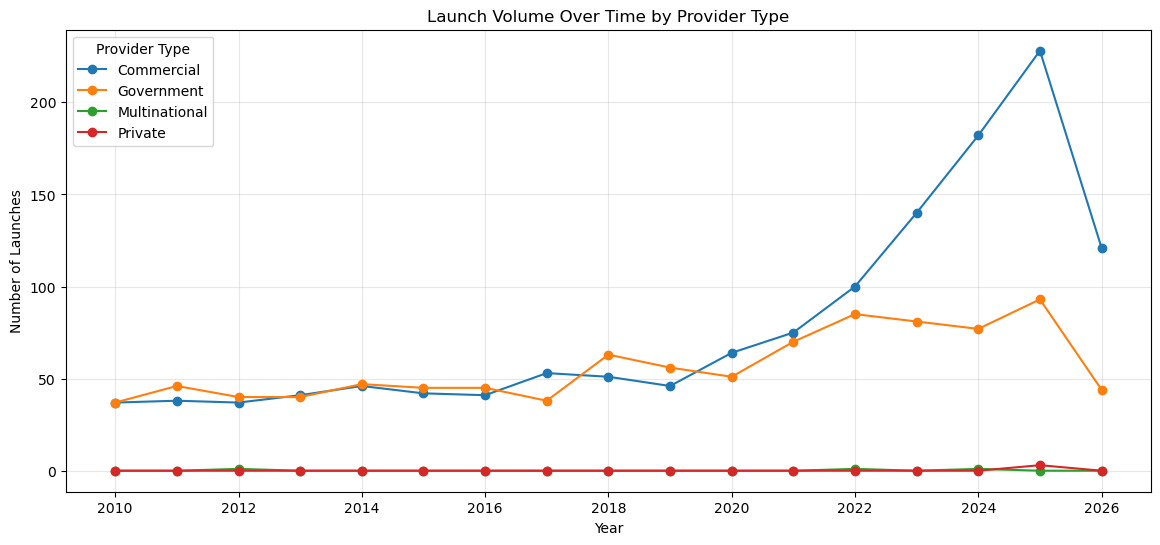

In [45]:
provider_type_year = (
    launches_df
    .groupby(["year", "provider_type"])
    .size()
    .reset_index(name="launch_count")
)

provider_type_pivot = provider_type_year.pivot(
    index='year',
    columns='provider_type',
    values='launch_count'
).fillna(0)

plt.figure(figsize=(14, 6))

for provider_type in provider_type_pivot.columns:
    plt.plot(
        provider_type_pivot.index,
        provider_type_pivot[provider_type],
        marker='o',
        label=provider_type
    )

plt.title('Launch Volume Over Time by Provider Type')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.grid(True, alpha=0.3)
plt.legend(title='Provider Type')
plt.show()

In [46]:
commercial_2022 = launches_df[
    (launches_df['year'] == 2022) & 
    (launches_df['provider_type'] == 'Commercial')
]

commercial_2022['launch_provider'].value_counts().head(10)

launch_provider
SpaceX                            61
Rocket Lab                         9
United Launch Alliance             8
Arianespace                        5
Astra Space                        3
ExPace                             3
Virgin Orbit                       2
Northrop Grumman Space Systems     2
Galactic Energy                    2
i-Space                            1
Name: count, dtype: int64

https://www.space.com/spacex-celebrates-2022-61-launches

SpaceX had a record-breaking year in 2022 for rocket launches, which may explain the spike in commercial launches.

C:\Users\Kura\AppData\Local\Temp\ipykernel_8320\3632729755.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("provider_attempt_bin")["success"]


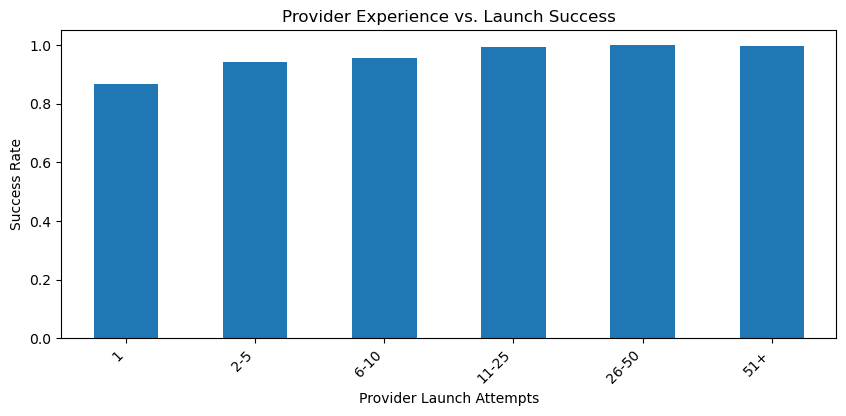

In [53]:
# Provider Experience vs. Success

launches_model2["provider_attempt_bin"] = pd.cut(
    launches_model2["yearly_provider_attempt_number"],
    bins=[0, 1, 5, 10, 25, 50, 1000],
    labels=["1", "2-5", "6-10", "11-25", "26-50", "51+"]
)

success_by_experience = (
    launches_model2
    .groupby("provider_attempt_bin")["success"]
    .mean()
)

plt.figure(figsize=(10, 4))

success_by_experience.plot(kind='bar')

plt.title('Provider Experience vs. Launch Success')
plt.xlabel('Provider Launch Attempts')
plt.ylabel('Success Rate')
plt.xticks(rotation=45, ha='right')
plt.show()